# 02 — Simulated Annealing: casas y hospitales

**Curso:** Inteligencia Artificial — Optimización

En este ejercicio usaremos el mismo problema de ubicación de hospitales del notebook de Hill Climbing. Así podremos comparar ambos algoritmos sobre el mismo espacio de estados, función de costo y vecindario.

![HillClimbing](https://drive.google.com/uc?export=view&id=13a1dTy2bf9BsgeSZH-cXqJndS1ZKU4DP)



## Objetivos

- implementar Simulated Annealing para un problema discreto;
- comprender la aceptación probabilística de soluciones peores;
- analizar el efecto de la temperatura y el enfriamiento;
- comparar Hill Climbing y Simulated Annealing sobre el mismo problema.

## 1. Problema de ubicación de hospitales

Tenemos una cuadrícula con varias casas y queremos ubicar $k$ hospitales.

El costo de una solución es la suma de la distancia de cada casa al hospital más cercano:

$$
J(H)=\sum_{c\in C}\min_{h\in H} d(c,h)
$$

Usaremos distancia Manhattan:

$$
d((r_1,c_1),(r_2,c_2))=|r_1-r_2|+|c_1-c_2|
$$

El objetivo es **minimizar** $J(H)$.

In [2]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

SEED = 8
random.seed(SEED)
np.random.seed(SEED)

In [3]:
def manhattan(a, b):
    return abs(a[0] - b[0]) + abs(a[1] - b[1])


def total_cost(houses, hospitals):
    return sum(
        min(manhattan(house, hospital) for hospital in hospitals)
        for house in houses
    )


def plot_state(height, width, houses, hospitals, title=None):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.set_xlim(-0.5, width - 0.5)
    ax.set_ylim(height - 0.5, -0.5)
    ax.set_xticks(range(width))
    ax.set_yticks(range(height))
    ax.grid(True)

    if houses:
        rows, cols = zip(*houses)
        ax.scatter(cols, rows, marker="s", s=110, label="Casas")

    if hospitals:
        rows, cols = zip(*hospitals)
        ax.scatter(cols, rows, marker="P", s=180, label="Hospitales")

    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
    ax.set_title(title or f"Costo = {total_cost(houses, hospitals)}")
    plt.tight_layout()
    plt.show()

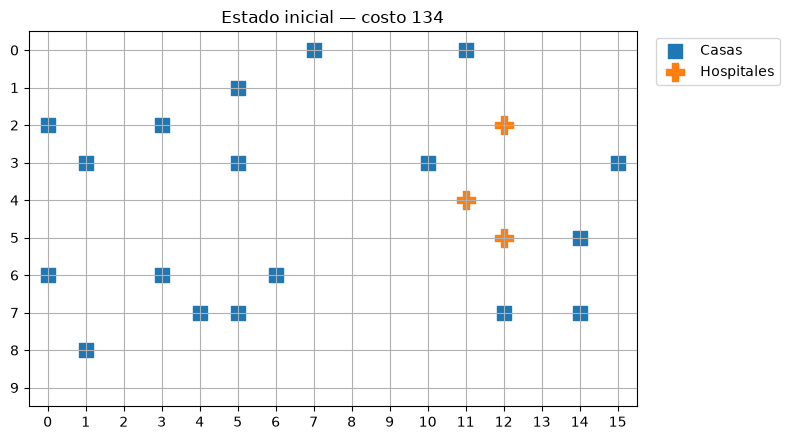

In [4]:
HEIGHT, WIDTH = 10, 16
NUM_HOUSES = 18
NUM_HOSPITALS = 3

all_cells = [
    (row, col)
    for row in range(HEIGHT)
    for col in range(WIDTH)
]

houses = set(random.sample(all_cells, NUM_HOUSES))
available = list(set(all_cells) - houses)
initial_hospitals = set(
    random.sample(available, NUM_HOSPITALS)
)

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    initial_hospitals,
    title=(
        "Estado inicial — costo "
        f"{total_cost(houses, initial_hospitals)}"
    ),
)

## 2. Vecindario

Un estado está formado por las posiciones de los hospitales.

Un vecino se obtiene moviendo **un hospital** una celda hacia arriba, abajo, izquierda o derecha, siempre que la nueva posición:

- esté dentro de la cuadrícula;
- no contenga una casa;
- no esté ocupada por otro hospital.

In [5]:
def neighbors_of_state(height, width, houses, hospitals):
    neighbors = []
    moves = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for hospital in hospitals:
        for dr, dc in moves:
            candidate = (
                hospital[0] + dr,
                hospital[1] + dc,
            )

            if not (
                0 <= candidate[0] < height
                and 0 <= candidate[1] < width
            ):
                continue

            if candidate in houses or candidate in hospitals:
                continue

            new_state = set(hospitals)
            new_state.remove(hospital)
            new_state.add(candidate)
            neighbors.append(new_state)

    return neighbors


neighbors = neighbors_of_state(
    HEIGHT,
    WIDTH,
    houses,
    initial_hospitals,
)

print("Número de vecinos:", len(neighbors))
print("Costo actual:", total_cost(houses, initial_hospitals))
print(
    "Mejor costo vecino:",
    min(total_cost(houses, state) for state in neighbors),
)

Número de vecinos: 12
Costo actual: 134
Mejor costo vecino: 125


## 3. Hill Climbing como línea base

Hill Climbing siempre se mueve al mejor vecino disponible.

Si ningún vecino mejora el costo actual, se detiene.

Costo inicial: 134
Costo final: 62
Iteraciones: 13


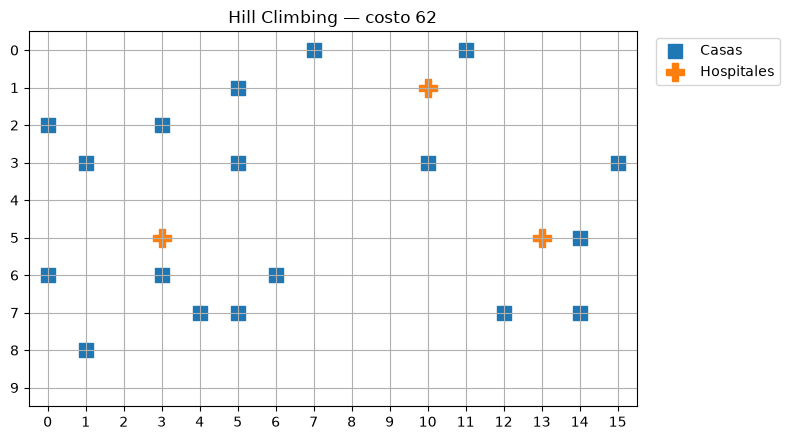

In [6]:
def hill_climbing(
    height,
    width,
    houses,
    initial_state,
    max_iterations=200,
    rng=None,
):
    rng = rng or random.Random()
    current = set(initial_state)
    current_cost = total_cost(houses, current)

    history = [current_cost]
    states = [set(current)]

    for _ in range(max_iterations):
        neighbors = neighbors_of_state(
            height,
            width,
            houses,
            current,
        )

        if not neighbors:
            break

        costs = [
            total_cost(houses, neighbor)
            for neighbor in neighbors
        ]
        best_cost = min(costs)

        if best_cost >= current_cost:
            break

        best_neighbors = [
            neighbor
            for neighbor, cost in zip(neighbors, costs)
            if cost == best_cost
        ]

        current = set(rng.choice(best_neighbors))
        current_cost = best_cost
        history.append(current_cost)
        states.append(set(current))

    return current, history, states


hc_solution, hc_history, hc_states = hill_climbing(
    HEIGHT,
    WIDTH,
    houses,
    initial_hospitals,
    rng=random.Random(SEED),
)

print("Costo inicial:", hc_history[0])
print("Costo final:", hc_history[-1])
print("Iteraciones:", len(hc_history) - 1)

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    hc_solution,
    title=f"Hill Climbing — costo {hc_history[-1]}",
)

## 4. Regla de aceptación de Simulated Annealing

Sea:

$$
\Delta = J(H') - J(H)
$$

Como estamos minimizando:

- si $\Delta \leq 0$, el nuevo estado es igual o mejor y se acepta;
- si $\Delta > 0$, el nuevo estado es peor, pero puede aceptarse con probabilidad:

$$
P(\text{aceptar})=e^{-\Delta/T}
$$

Cuando $T$ es alta, el algoritmo explora. Cuando $T$ disminuye, se vuelve más conservador.

In [7]:
def acceptance_probability(delta_cost, temperature):
    if delta_cost <= 0:
        return 1.0

    if temperature <= 0:
        return 0.0

    return math.exp(-delta_cost / temperature)


for temperature in [0.1, 1, 5, 20]:
    probability = acceptance_probability(
        delta_cost=3,
        temperature=temperature,
    )
    print(
        f"T={temperature:>4}: "
        f"P(aceptar un aumento de 3)={probability:.3f}"
    )

T= 0.1: P(aceptar un aumento de 3)=0.000
T=   1: P(aceptar un aumento de 3)=0.050
T=   5: P(aceptar un aumento de 3)=0.549
T=  20: P(aceptar un aumento de 3)=0.861


## 5. Implementación

En cada iteración:

1. generamos los vecinos;
2. seleccionamos **uno al azar**;
3. calculamos $\Delta$;
4. aplicamos la regla de aceptación;
5. reducimos la temperatura.

Costo inicial: 134
Mejor costo: 56
Iteraciones: 1500


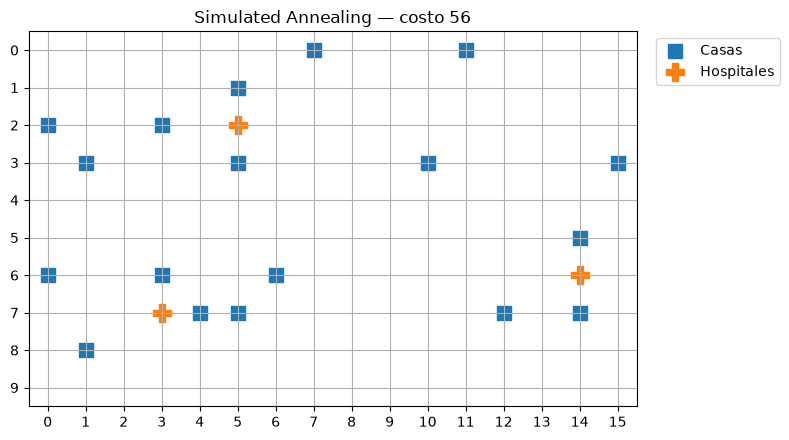

In [8]:
def simulated_annealing(
    height,
    width,
    houses,
    initial_state,
    iterations=1000,
    initial_temperature=20.0,
    cooling_rate=0.995,
    minimum_temperature=1e-3,
    rng=None,
):
    rng = rng or random.Random()

    current = set(initial_state)
    current_cost = total_cost(houses, current)

    best = set(current)
    best_cost = current_cost

    temperature = initial_temperature
    records = []

    for iteration in range(iterations):
        neighbors = neighbors_of_state(
            height,
            width,
            houses,
            current,
        )

        if not neighbors or temperature < minimum_temperature:
            break

        candidate = set(rng.choice(neighbors))
        candidate_cost = total_cost(houses, candidate)
        delta_cost = candidate_cost - current_cost

        probability = acceptance_probability(
            delta_cost,
            temperature,
        )
        accepted = rng.random() < probability

        if accepted:
            current = candidate
            current_cost = candidate_cost

            if current_cost < best_cost:
                best = set(current)
                best_cost = current_cost

        records.append({
            "iteration": iteration,
            "temperature": temperature,
            "current_cost": current_cost,
            "best_cost": best_cost,
            "delta_cost": delta_cost,
            "accepted": accepted,
        })

        temperature *= cooling_rate

    return best, records


sa_solution, sa_records = simulated_annealing(
    HEIGHT,
    WIDTH,
    houses,
    initial_hospitals,
    iterations=1500,
    initial_temperature=20,
    cooling_rate=0.995,
    rng=random.Random(SEED),
)

print("Costo inicial:", total_cost(houses, initial_hospitals))
print("Mejor costo:", total_cost(houses, sa_solution))
print("Iteraciones:", len(sa_records))

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    sa_solution,
    title=(
        "Simulated Annealing — costo "
        f"{total_cost(houses, sa_solution)}"
    ),
)

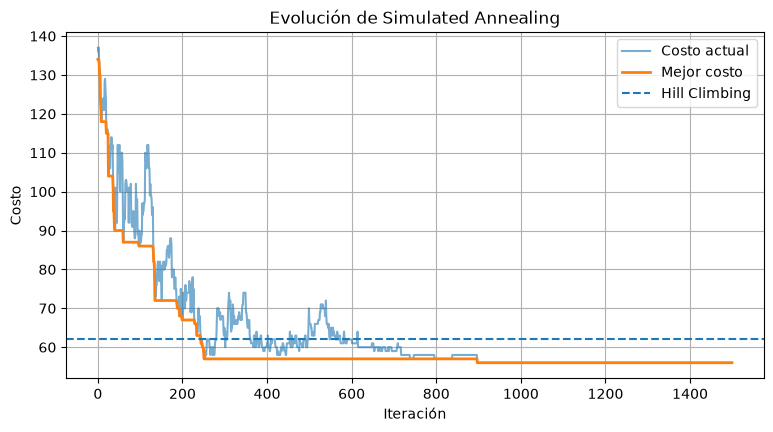

In [9]:
iterations = [record["iteration"] for record in sa_records]
current_costs = [record["current_cost"] for record in sa_records]
best_costs = [record["best_cost"] for record in sa_records]

plt.figure(figsize=(9, 4.5))
plt.plot(iterations, current_costs, alpha=0.6, label="Costo actual")
plt.plot(iterations, best_costs, linewidth=2, label="Mejor costo")
plt.axhline(
    hc_history[-1],
    linestyle="--",
    label="Hill Climbing",
)
plt.xlabel("Iteración")
plt.ylabel("Costo")
plt.title("Evolución de Simulated Annealing")
plt.legend()
plt.grid(True)
plt.show()

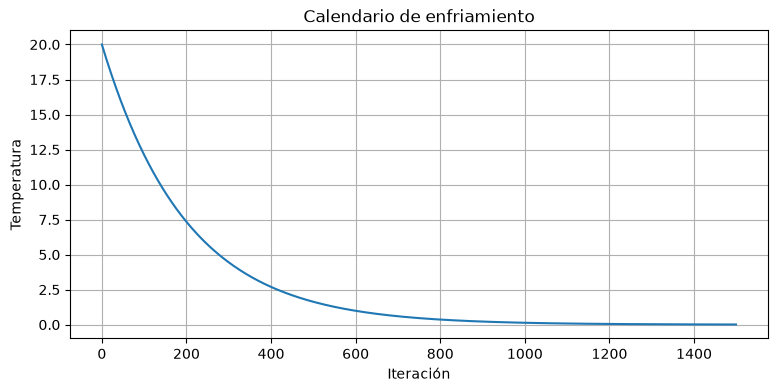

Porcentaje de movimientos aceptados: 36.2%


In [10]:
temperatures = [record["temperature"] for record in sa_records]
accepted = [record["accepted"] for record in sa_records]

plt.figure(figsize=(9, 4))
plt.plot(iterations, temperatures)
plt.xlabel("Iteración")
plt.ylabel("Temperatura")
plt.title("Calendario de enfriamiento")
plt.grid(True)
plt.show()

print(
    "Porcentaje de movimientos aceptados:",
    f"{100 * np.mean(accepted):.1f}%",
)

## 6. Comparación estadística

Una sola corrida puede ser engañosa. Ejecutaremos ambos algoritmos desde diferentes estados iniciales.

In [11]:
def random_initial_state(
    height,
    width,
    houses,
    num_hospitals,
    rng,
):
    cells = [
        (row, col)
        for row in range(height)
        for col in range(width)
        if (row, col) not in houses
    ]
    return set(rng.sample(cells, num_hospitals))


hc_results = []
sa_results = []

for seed in range(30):
    rng = random.Random(seed)
    start = random_initial_state(
        HEIGHT,
        WIDTH,
        houses,
        NUM_HOSPITALS,
        rng,
    )

    hc_solution_i, hc_history_i, _ = hill_climbing(
        HEIGHT,
        WIDTH,
        houses,
        start,
        rng=random.Random(seed),
    )

    sa_solution_i, _ = simulated_annealing(
        HEIGHT,
        WIDTH,
        houses,
        start,
        iterations=1200,
        initial_temperature=20,
        cooling_rate=0.995,
        rng=random.Random(seed),
    )

    hc_results.append(total_cost(houses, hc_solution_i))
    sa_results.append(total_cost(houses, sa_solution_i))

print("Hill Climbing — promedio:", np.mean(hc_results))
print("Simulated Annealing — promedio:", np.mean(sa_results))
print("Hill Climbing — mejor:", min(hc_results))
print("Simulated Annealing — mejor:", min(sa_results))

Hill Climbing — promedio: 72.2
Simulated Annealing — promedio: 56.333333333333336
Hill Climbing — mejor: 57
Simulated Annealing — mejor: 56


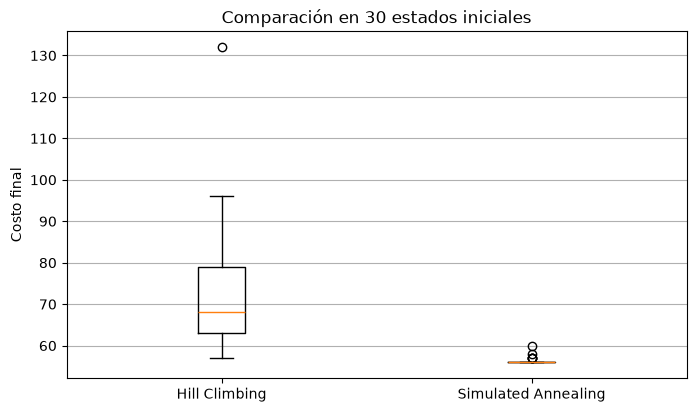

In [12]:
plt.figure(figsize=(8, 4.5))

plt.boxplot(
    [hc_results, sa_results],
    tick_labels=["Hill Climbing", "Simulated Annealing"],
)

plt.ylabel("Costo final")
plt.title("Comparación en 30 estados iniciales")
plt.grid(True, axis="y")
plt.show()

## Actividades

### Actividad 1 — Temperatura inicial

Compara:

$$
T_0\in\{0.1,1,5,20,100\}
$$

Para cada valor, ejecuta 20 corridas y registra:

- costo promedio;
- mejor costo;
- porcentaje de movimientos aceptados.

In [13]:
# TODO
initial_temperatures = [0.1, 1, 5, 20, 100]
results = []

for initial_temperature in initial_temperatures:
    costs = []
    acceptance_rates = []

    for run in range(20):
        # Usamos una semilla diferente en cada corrida
        rng = random.Random(SEED + run)

        sa_solution, sa_records = simulated_annealing(
            HEIGHT,
            WIDTH,
            houses,
            initial_hospitals,
            iterations=1500,
            initial_temperature=initial_temperature,
            cooling_rate=0.995,
            rng=rng,
        )

        # Costo final de la mejor solución encontrada
        final_cost = total_cost(houses, sa_solution)
        costs.append(final_cost)

        # Porcentaje de movimientos aceptados
        if sa_records:
            accepted = sum(record["accepted"] for record in sa_records)
            acceptance_rate = (accepted / len(sa_records)) * 100
        else:
            acceptance_rate = 0

        acceptance_rates.append(acceptance_rate)

    results.append({
        "Temperatura inicial": initial_temperature,
        "Costo promedio": np.mean(costs),
        "Mejor costo": min(costs),
        "% movimientos aceptados": np.mean(acceptance_rates),
    })

results

[{'Temperatura inicial': 0.1,
  'Costo promedio': np.float64(63.0),
  'Mejor costo': 56,
  '% movimientos aceptados': np.float64(17.415669205658325)},
 {'Temperatura inicial': 1,
  'Costo promedio': np.float64(61.15),
  'Mejor costo': 56,
  '% movimientos aceptados': np.float64(19.633792603335753)},
 {'Temperatura inicial': 5,
  'Costo promedio': np.float64(57.8),
  'Mejor costo': 56,
  '% movimientos aceptados': np.float64(37.61000000000001)},
 {'Temperatura inicial': 20,
  'Costo promedio': np.float64(56.2),
  'Mejor costo': 56,
  '% movimientos aceptados': np.float64(48.54333333333334)},
 {'Temperatura inicial': 100,
  'Costo promedio': np.float64(56.05),
  'Mejor costo': 56,
  '% movimientos aceptados': np.float64(65.16333333333334)}]

### Actividad 2 — Enfriamiento

Compara:

$$
\alpha\in\{0.90,0.95,0.98,0.995,0.999\}
$$

¿Qué ocurre cuando la temperatura disminuye demasiado rápido? ¿Qué ocurre cuando disminuye demasiado lento?

In [16]:
# TODO
cooling_rates = [0.90, 0.95, 0.98, 0.995, 0.999]

results_cooling = []

for cooling_rate in cooling_rates:
    costs = []
    acceptance_rates = []

    for run in range(20):
        rng = random.Random(SEED + run)

        sa_solution, sa_records = simulated_annealing(
            HEIGHT,
            WIDTH,
            houses,
            initial_hospitals,
            iterations=1500,
            initial_temperature=20,
            cooling_rate=cooling_rate,
            rng=rng,
        )

        final_cost = total_cost(houses, sa_solution)
        costs.append(final_cost)

        if sa_records:
            accepted = sum(
                record["accepted"] for record in sa_records
            )
            acceptance_rate = (accepted / len(sa_records)) * 100
        else:
            acceptance_rate = 0

        acceptance_rates.append(acceptance_rate)

    results_cooling.append({
        "Cooling rate": cooling_rate,
        "Costo promedio": np.mean(costs),
        "Mejor costo": min(costs),
        "% movimientos aceptados": np.mean(acceptance_rates),
    })

results_cooling

[{'Cooling rate': 0.9,
  'Costo promedio': np.float64(68.4),
  'Mejor costo': 60,
  '% movimientos aceptados': np.float64(47.3936170212766)},
 {'Cooling rate': 0.95,
  'Costo promedio': np.float64(63.15),
  'Mejor costo': 60,
  '% movimientos aceptados': np.float64(42.98969072164948)},
 {'Cooling rate': 0.98,
  'Costo promedio': np.float64(60.75),
  'Mejor costo': 56,
  '% movimientos aceptados': np.float64(41.598778004073324)},
 {'Cooling rate': 0.995,
  'Costo promedio': np.float64(56.2),
  'Mejor costo': 56,
  '% movimientos aceptados': np.float64(48.54333333333334)},
 {'Cooling rate': 0.999,
  'Costo promedio': np.float64(57.65),
  'Mejor costo': 56,
  '% movimientos aceptados': np.float64(87.39333333333333)}]

### Actividad 3 — Comparación justa

Para 50 estados iniciales:

1. ejecuta Hill Climbing;
2. ejecuta Simulated Annealing desde el mismo estado;
3. cuenta cuántas veces gana cada algoritmo;
4. compara el costo promedio.

Costo inicial: 134
Costo final: 62
Iteraciones: 13


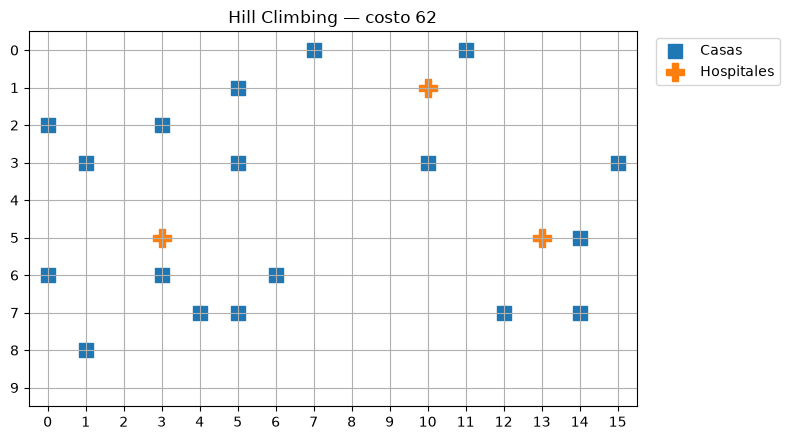

In [18]:
def hill_climbing(
    height,
    width,
    houses,
    initial_state,
    max_iterations=200,
    rng=None,
):
    rng = rng or random.Random()
    current = set(initial_state)
    current_cost = total_cost(houses, current)

    history = [current_cost]
    states = [set(current)]

    for _ in range(max_iterations):
        neighbors = neighbors_of_state(
            height,
            width,
            houses,
            current,
        )

        if not neighbors:
            break

        costs = [
            total_cost(houses, neighbor)
            for neighbor in neighbors
        ]
        best_cost = min(costs)

        if best_cost >= current_cost:
            break

        best_neighbors = [
            neighbor
            for neighbor, cost in zip(neighbors, costs)
            if cost == best_cost
        ]

        current = set(rng.choice(best_neighbors))
        current_cost = best_cost
        history.append(current_cost)
        states.append(set(current))

    return current, history, states


hc_solution, hc_history, hc_states = hill_climbing(
    HEIGHT,
    WIDTH,
    houses,
    initial_hospitals,
    rng=random.Random(SEED),
)

print("Costo inicial:", hc_history[0])
print("Costo final:", hc_history[-1])
print("Iteraciones:", len(hc_history) - 1)

plot_state(
    HEIGHT,
    WIDTH,
    houses,
    hc_solution,
    title=f"Hill Climbing — costo {hc_history[-1]}",
)

## Preguntas de cierre

1. ¿Por qué Simulated Annealing puede aceptar un hospital en una posición que aumenta temporalmente el costo?

Simulated Annealing puede aceptar movimientos que aumentan el costo para evitar quedar atrapado en un **óptimo local**. La probabilidad de aceptar una solución peor depende de la temperatura y de cuánto aumenta el costo. Al principio, cuando la temperatura es alta, es más probable aceptar movimientos peores. Esto permite explorar diferentes regiones del espacio de búsqueda.

2. ¿Qué función cumple la temperatura?

La temperatura controla la probabilidad de aceptar movimientos que empeoran temporalmente la solución. Con una temperatura alta, el algoritmo explora más y acepta con mayor facilidad soluciones peores. A medida que la temperatura disminuye, se vuelve más selectivo y se concentra en mejorar la solución actual.

3. ¿Por qué debemos conservar la mejor solución observada y no solamente el estado final?

Porque el estado final no necesariamente es la mejor solución que el algoritmo encontró durante la búsqueda. Simulated Annealing puede aceptar movimientos peores, especialmente cuando la temperatura es alta, por lo que podría terminar en una solución con mayor costo que una encontrada anteriormente. Conservar la mejor solución garantiza que no perdamos el mejor resultado encontrado.

4. ¿Simulated Annealing garantiza encontrar el óptimo global con un número finito de iteraciones?

No. Con un número finito de iteraciones, Simulated Annealing **no garantiza** encontrar el óptimo global. Puede aumentar la probabilidad de encontrar buenas soluciones al explorar diferentes regiones del espacio de búsqueda, pero existe la posibilidad de terminar sin encontrar la solución óptima.

5. ¿Qué diferencia fundamental hay entre escoger el mejor vecino y escoger un vecino al azar?

Hill Climbing selecciona el **mejor vecino** disponible, por lo que siempre intenta mejorar inmediatamente la solución actual. Simulated Annealing, en cambio, selecciona un **vecino al azar** y decide si lo acepta según el cambio de costo y la temperatura. Esto permite que Simulated Annealing explore soluciones que no necesariamente mejoran inmediatamente el costo y pueda escapar de óptimos locales.